In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [1]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


# 12.1 — Transform , Dataset

In [3]:
train_dataset = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)
val_dataset = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)

In [4]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [5]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


# 12.2 — CNN + AvgPool2d

In [6]:
class PoolingCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 12.3 — model, loss, optimizer, decive

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model_pooling = PoolingCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_pooling.parameters(),
    lr=0.001
)

print(model_pooling)

PoolingCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=7, bias=True)
  )
)


# 12.4 — Training loop 

In [8]:
num_epochs = 10
best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    model_pooling.train()
    running_train_loss = 0.0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_pooling(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # Validation
    model_pooling.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_pooling(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    # save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model_pooling.state_dict(),
            "best_pooling_model.pt"
        )
        print("  --> Best pooling model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("\nBest Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

  --> Best pooling model saved!
Epoch [1/10] Train Loss: 1.5890 Val Loss: 0.8151 Val Accuracy: 0.7235
  --> Best pooling model saved!
Epoch [2/10] Train Loss: 0.5008 Val Loss: 0.5714 Val Accuracy: 0.8049
  --> Best pooling model saved!
Epoch [3/10] Train Loss: 0.2276 Val Loss: 0.5467 Val Accuracy: 0.8101
  --> Best pooling model saved!
Epoch [4/10] Train Loss: 0.1303 Val Loss: 0.6320 Val Accuracy: 0.8359
  --> Best pooling model saved!
Epoch [5/10] Train Loss: 0.0505 Val Loss: 0.5845 Val Accuracy: 0.8398
  --> Best pooling model saved!
Epoch [6/10] Train Loss: 0.0156 Val Loss: 0.6190 Val Accuracy: 0.8450
  --> Best pooling model saved!
Epoch [7/10] Train Loss: 0.0058 Val Loss: 0.6071 Val Accuracy: 0.8514
Epoch [8/10] Train Loss: 0.0030 Val Loss: 0.6207 Val Accuracy: 0.8501
  --> Best pooling model saved!
Epoch [9/10] Train Loss: 0.0018 Val Loss: 0.6482 Val Accuracy: 0.8527
Epoch [10/10] Train Loss: 0.0014 Val Loss: 0.6703 Val Accuracy: 0.8475


Best Epoch: 9
Best Validation Accuracy: 0

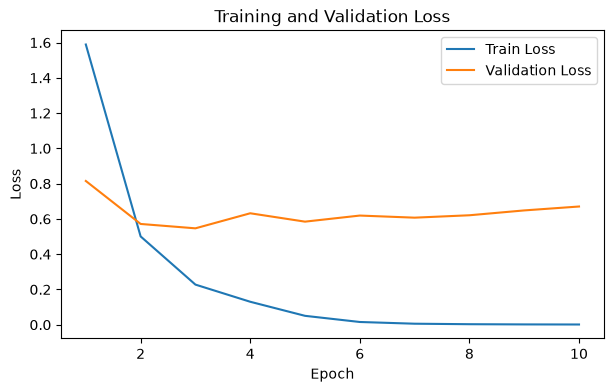

In [9]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

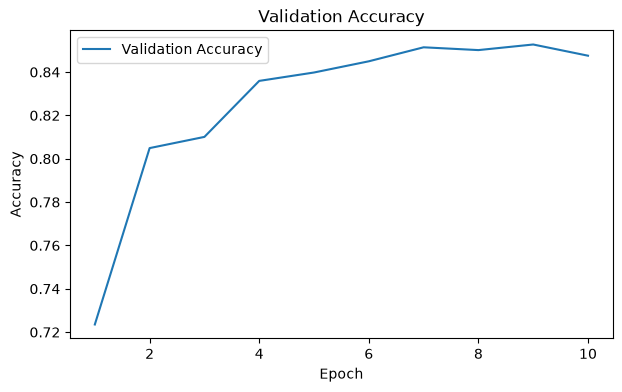

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 12.5 — Baseline evaluation on the validation set

In [ ]:
model_pooling.load_state_dict(
    torch.load(
        'best_pooling_model.pt',
        map_location=device
    )
)
best_model_pooling = model_pooling.to(device)
best_model_pooling.eval()
print("Best Dropout Model Loaded")

Best Dropout Model Loaded


In [ ]:
all_predictions_pooling = []
all_labels_pooling  = []
best_model_pooling.eval()
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model_pooling(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_pooling.extend(predictions.cpu().numpy())
        all_labels_pooling.extend(labels.cpu().numpy())

print("Predictions:", len(all_predictions_pooling))
print("Labels:", len(all_labels_pooling))

Predictions: 774
Labels: 774


# 12.6 — Precision , Recall , F1 , confusion_matrix

In [14]:
accuracy = accuracy_score(all_labels_pooling, all_predictions_pooling)
precision = precision_score(all_labels_pooling, all_predictions_pooling, average="macro")
recall = recall_score(all_labels_pooling, all_predictions_pooling, average="macro")
f1 = f1_score(all_labels_pooling, all_predictions_pooling, average="macro")
cm = confusion_matrix(all_labels_pooling, all_predictions_pooling)

print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Validation Accuracy : 0.8527131782945736
Validation Precision: 0.8601104315698725
Validation Recall   : 0.8501183623180163
Validation F1 Score : 0.8534923551576913
confusion_matrix    :
 [[ 55   2   9   3   1   0   2]
 [  0  75  12   3   1   1   1]
 [  4   5 160  12   1   1   6]
 [  0   0   8  70   0   0   0]
 [  2   2   2   0  85   0   9]
 [  0   2   2   1   3  89   0]
 [  1   0   5   1  11   1 126]]


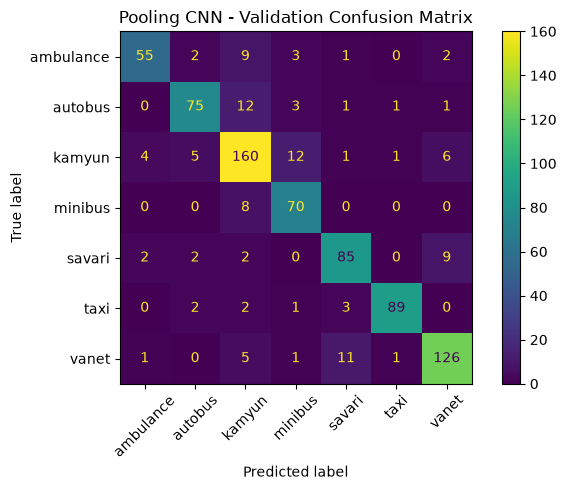

In [15]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Pooling CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# classification_report

In [16]:
report = classification_report(all_labels_pooling, all_predictions_pooling, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.89      0.76      0.82        72
     autobus       0.87      0.81      0.84        93
      kamyun       0.81      0.85      0.83       189
     minibus       0.78      0.90      0.83        78
      savari       0.83      0.85      0.84       100
        taxi       0.97      0.92      0.94        97
       vanet       0.88      0.87      0.87       145

    accuracy                           0.85       774
   macro avg       0.86      0.85      0.85       774
weighted avg       0.86      0.85      0.85       774

